# Elliptic Dataset

## Resumen

Desde kaggle, tenemos la siguiente descripción:

The Elliptic Data Set maps Bitcoin transactions to real entities belonging to licit categories (exchanges, wallet providers, miners, licit services, etc.) versus illicit ones (scams, malware, terrorist organizations, ransomware, Ponzi schemes, etc.). The task on the dataset is to classify the illicit and licit nodes in the graph.

**Nodes and edges**

The graph is made of 203,769 nodes and 234,355 edges. Two percent (4,545) of the nodes are labelled class1 (illicit). Twenty-one percent (42,019) are labelled class2 (licit). The remaining transactions are not labelled with regard to licit versus illicit.

**Features**

There are 166 features associated with each node. Due to intellectual property issues, we cannot provide an exact description of all the features in the dataset. There is a time step associated to each node, representing a measure of the time when a transaction was broadcasted to the Bitcoin network. The time steps, running from 1 to 49, are evenly spaced with an interval of about two weeks. Each time step contains a single connected component of transactions that appeared on the blockchain within less than three hours between each other; there are no edges connecting the different time steps.

The first 94 features represent local information about the transaction – including the time step described above, number of inputs/outputs, transaction fee, output volume and aggregated figures such as average BTC received (spent) by the inputs/outputs and average number of incoming (outgoing) transactions associated with the inputs/outputs. The remaining 72 features are aggregated features, obtained using transaction information one-hop backward/forward from the center node - giving the maximum, minimum, standard deviation and correlation coefficients of the neighbour transactions for the same information data (number of inputs/outputs, transaction fee, etc.).

## Aproximación

Vamos a abordar este problema aplicando una solución distribuida y escalable con Apache Spark. Lo que debemos destacar de la descripción es que se trata de un problema semisupervisado en un entorno transductivo, con datos cuya topología es un grafo (no dirigido, a priori). Formularemos la hipótesis pertinente tras el análisis de los datos.

## Análisis Exploratorio de los Datos

In [2]:
import os
from pyspark.sql import SparkSession


IN_COLAB = "COLAB_GPU" in os.environ or os.path.exists("/content")
builder = SparkSession.builder.appName("EllipticGNN")

if IN_COLAB:
    builder = builder \
        .master("local[*]") \
        .config("spark.driver.memory", "8g") \
        .config("spark.driver.maxResultSize", "2g") \
        .config("spark.sql.shuffle.partitions", "8") \
        .config("spark.jars.packages", "graphframes:graphframes:0.8.3-spark3.5-s_2.12") \
        .config("spark.sql.execution.arrow.pyspark.enabled", "true")
else:
    builder = builder \
        .config("spark.driver.memory", "16g") \
        .config("spark.executor.memory", "8g") \
        .config("spark.executor.cores", "4") \
        .config("spark.sql.shuffle.partitions", "200") \
        .config("spark.driver.maxResultSize", "4g") \
        .config("spark.jars.packages", "graphframes:graphframes:0.8.3-spark3.5-s_2.12") \
        .config("spark.sql.execution.arrow.pyspark.enabled", "true")

spark = builder.getOrCreate()
sc = spark.sparkContext

In [3]:
import kagglehub
import pandas as pd


path = kagglehub.dataset_download("ellipticco/elliptic-data-set")

df_classes = spark.read.csv(path + "/elliptic_bitcoin_dataset/elliptic_txs_classes.csv",
                            header=True, inferSchema=True)
df_edges = spark.read.csv(path + "/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv",
                          header=True, inferSchema=True)
df_features = spark.read.csv(path + "/elliptic_bitcoin_dataset/elliptic_txs_features.csv",
                             header=False, inferSchema=True)

Using Colab cache for faster access to the 'elliptic-data-set' dataset.


In [4]:
df_classes = df_classes.withColumnRenamed("txId", "id")
df_classes.show(5)

print(f"Classes shape: ({df_classes.count()}, {len(df_classes.columns)})")

+---------+-------+
|       id|  class|
+---------+-------+
|230425980|unknown|
|  5530458|unknown|
|232022460|unknown|
|232438397|      2|
|230460314|unknown|
+---------+-------+
only showing top 5 rows

Classes shape: (203769, 2)


In [5]:
df_classes.select("class").distinct().show()

+-------+
|  class|
+-------+
|      1|
|unknown|
|      2|
+-------+



In [6]:
df_edges = df_edges.withColumnRenamed("txId1", "src")
df_edges = df_edges.withColumnRenamed("txId2", "dst")
df_edges.show(5)

print(f"Edges shape: ({df_edges.count()}, {len(df_edges.columns)})")

+---------+---------+
|      src|      dst|
+---------+---------+
|230425980|  5530458|
|232022460|232438397|
|230460314|230459870|
|230333930|230595899|
|232013274|232029206|
+---------+---------+
only showing top 5 rows

Edges shape: (234355, 2)


In [7]:
df_features = df_features.withColumnRenamed("_c0", "id")
df_features.show(5)

print(f"Features shape: ({df_features.count()}, {len(df_features.columns)})")

+---------+---+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+-

Como podemos observar, la mayoría de las características no tienen realmente mucho significado semántico. Sin embargo, por Kaggle, sabemos que hay otra característica importante, que es la marca de tiempo (timestamp). La columna '1' parece sospechosa, la revisaremos.

In [8]:
df_features.describe("_c1").show()

+-------+------------------+
|summary|               _c1|
+-------+------------------+
|  count|            203769|
|   mean|23.843960563186744|
| stddev|15.172170045043528|
|    min|                 1|
|    max|                49|
+-------+------------------+



In [9]:
df_features = df_features.withColumnRenamed("_c1", "timestep")
df_features.show(5)

+---------+--------+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------------------+--------------------+--------------------+-----------------

Comprobamos posibles valores nulos.

In [10]:
import pyspark.sql.functions as sql_f


df_null = df_features.select([
    sql_f.count(sql_f.when(sql_f.col(c).isNull() | sql_f.isnan(c), c)).alias(c) for c in df_features.columns
])

df_null.show()

+---+--------+---+---+---+---+---+---+---+---+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+
| id|timestep|_c2|_c3|_c4|_c5|_c6|_c7|_c8|_c9|_c10|_c11|_c12|_c13|_c14|_c15|_c16|_c17|_c18|_c19|_c20|

Ahora revisaremos las clases para ver cómo están distribuidas, ya que la descripción en Kaggle parece apuntar a un caso severo de desequilibrio de clases.

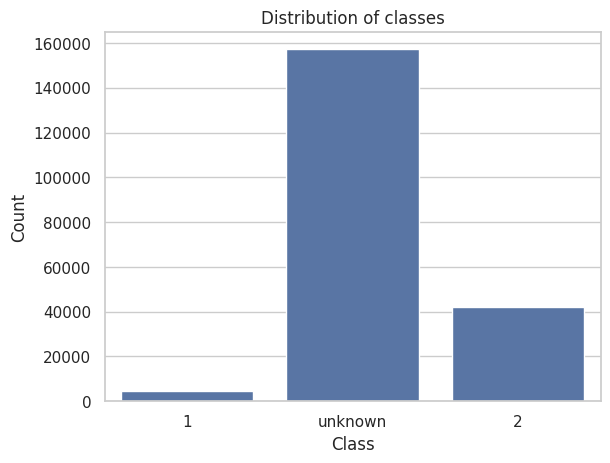

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")

df_count = df_classes.groupBy("class").count().toPandas()

sns.barplot(x="class", y="count", data=df_count)
plt.title("Distribution of classes")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

Agrupando por timesteps tenemos:

In [12]:
import pyspark.sql.functions as sql_f


# Añadimos las etiquetas a los atributos de los nodos para visualizar.
df_vis = df_features.select(sql_f.col("id"), sql_f.col("timestep")).\
                join(df_classes, df_features["id"] == df_classes["id"], "left").drop("id")

# Calculamos los counts de cada clase.
df_vis = df_vis.groupBy("timestep").agg(
    sql_f.count("*").alias("total"),
    sql_f.sum(sql_f.when(sql_f.col("class") == "1", 1).otherwise(0)).alias("illicit"),
    sql_f.sum(sql_f.when(sql_f.col("class") == "2", 1).otherwise(0)).alias("licit"),
    sql_f.sum(sql_f.when(sql_f.col("class") == "unknown", 1).otherwise(0)).alias("unknown")
).orderBy("timestep").toPandas()

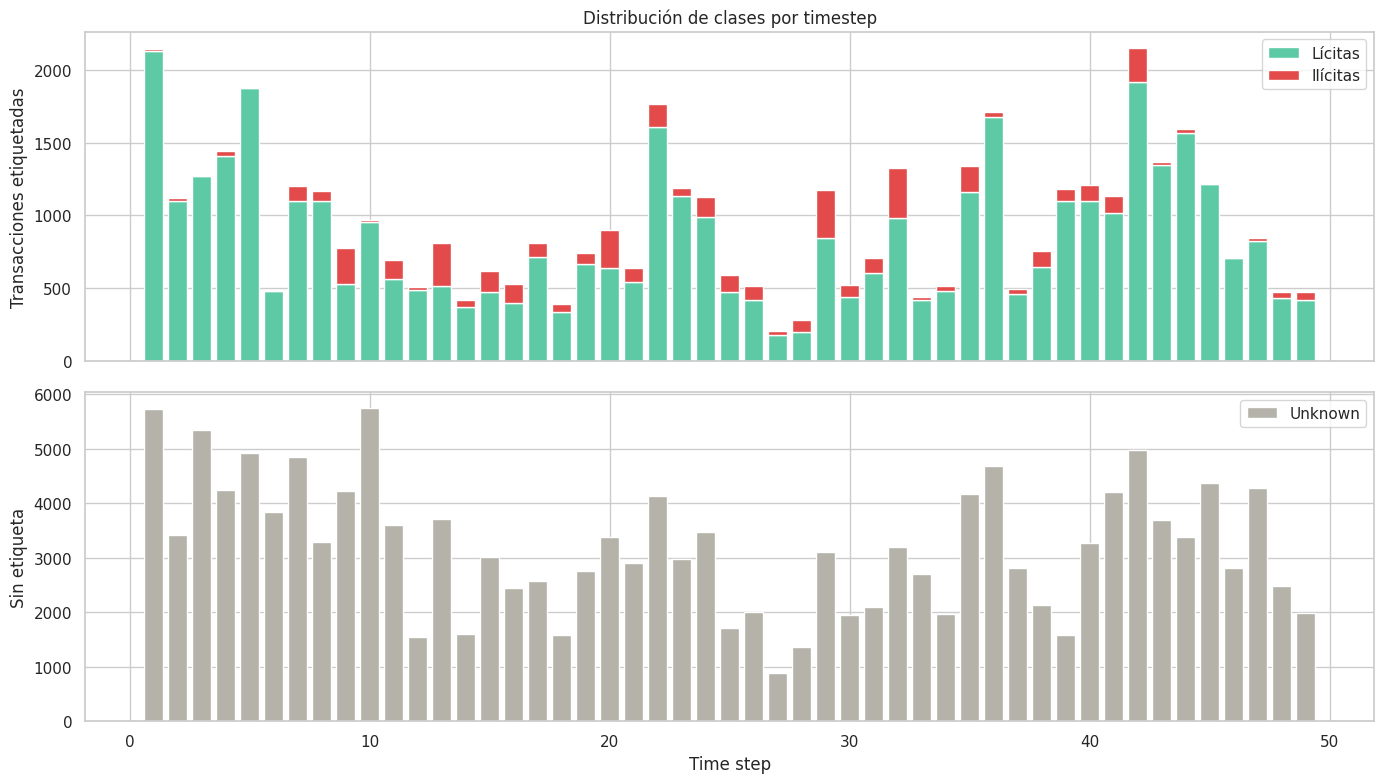

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].bar(df_vis["timestep"], df_vis["licit"], label="Lícitas", color="#5DCAA5")
axes[0].bar(df_vis["timestep"], df_vis["illicit"], bottom=df_vis["licit"],
            label="Ilícitas", color="#E24B4A")
axes[0].set_ylabel("Transacciones etiquetadas")
axes[0].legend()
axes[0].set_title("Distribución de clases por timestep")

axes[1].bar(df_vis["timestep"], df_vis["unknown"], color="#B4B2A9", label="Unknown")
axes[1].set_ylabel("Sin etiqueta")
axes[1].set_xlabel("Time step")
axes[1].legend()

plt.tight_layout()
plt.show()

Como podemos ver, el desequilibrio es un problema para todas las marcas de tiempo.

Si recordamos la descripción: "Cada paso de tiempo contiene un único componente conexo de transacciones que aparecieron en la blockchain con menos de tres horas de diferencia entre sí; no hay aristas que conecten los diferentes pasos de tiempo". Comprobaremos esto y exploraremos más a fondo la columna de la marca de tiempo (timestamp).

In [14]:
from graphframes import GraphFrame


# Join con las etiquetas
df_nodes = df_features.join(df_classes, "id", "left")

g = GraphFrame(df_nodes, df_edges)
g.vertices.show(5)
g.edges.show(5)

+---------+--------+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------------------+--------------------+--------------------+-----------------

In [15]:
# Spark obliga a establecer un directorio de checkpoint antes del
# cálculo de las componentes conexas.
spark.sparkContext.setCheckpointDir("/tmp/graphframes_checkpoints")
connected = g.connectedComponents()

# Contamos la cantidad de valores distintos de timestep que hay
# dentro de una componente conexa.
purity = connected.groupBy("component").agg(
    sql_f.countDistinct("timestep").alias("count_distinct")
)

purity.show(50)

+---------+--------------+
|component|count_distinct|
+---------+--------------+
|  2349601|             1|
|    52635|             1|
|   314705|             1|
|   143705|             1|
|   709696|             1|
|   730020|             1|
|  2009904|             1|
|   327038|             1|
|    16134|             1|
|   174370|             1|
|  2422228|             1|
|  1260557|             1|
|    70875|             1|
|   235586|             1|
|   738120|             1|
|   411947|             1|
| 11647079|             1|
|    11597|             1|
|   189229|             1|
|  1991588|             1|
|  4304541|             1|
|   113780|             1|
|   215305|             1|
|   127339|             1|
|  4850803|             1|
|    65253|             1|
|   643539|             1|
|   104216|             1|
|   121959|             1|
|   181624|             1|
|   122326|             1|
|   148681|             1|
|  1595982|             1|
|   755602|             1|
|

Vamos a intentar analizar algunas características para ver qué nos podemos encontrar.

In [16]:
sample_features = ["_c2", "_c3", "_c4", "_c5", "_c6"]
df_features.select(sample_features).describe().show()

+-------+--------------------+--------------------+--------------------+--------------------+--------------------+
|summary|                 _c2|                 _c3|                 _c4|                 _c5|                 _c6|
+-------+--------------------+--------------------+--------------------+--------------------+--------------------+
|  count|              203769|              203769|              203769|              203769|              203769|
|   mean|1.634706135498211...|-3.12349870819795...|3.904994943201051...|-1.99826087459173...|-6.81185673143292...|
| stddev|  1.0000024537679497|   1.000002453767944|  1.0000024537679466|  1.0000024537679453|  1.0000024537679408|
|    min|-0.17298263175632098|-0.21055257923974427| -1.7563614774316967|-0.12196959975910057|-0.06372457323883694|
|    max|   71.68196572491433|   73.59505187347129|   2.683579928609369|  49.027598384636185|   260.0907072901824|
+-------+--------------------+--------------------+--------------------+--------

Como vemos, hay una variedad importante en los valores que pueden tomar. Comprobamos ahora que no haya características de varianza ~0.

In [17]:
feature_cols = [f"_c{i}" for i in range(2, 167)]
var_exprs = [sql_f.variance(sql_f.col(c)).alias(c) for c in feature_cols]
vars = df_features.agg(*var_exprs).toPandas().T
vars.columns = ["variance"]
zero_var = vars[vars["variance"] < 1e-10]

print(f"\nCaracterísticas con var ~0: {len(zero_var)}")
if not zero_var.empty:
    print(zero_var.index.tolist())


Características con var ~0: 0


A continuación, intentamos generar una intuición de cómo de relevante es cada característica (de manera estrictamente tabular, es decir, no tenemos en cuenta topología) aplicando PCA:

In [18]:
from pyspark.ml.feature import VectorAssembler, PCA
import numpy as np


feature_cols = [f"_c{i}" for i in range(2, 167)]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
df_pca = assembler.transform(df_features)

# Establecemos k=165 para poder ver cuánta varianza explica cada componente
pca = PCA(k=len(feature_cols), inputCol="features", outputCol="pca_features")
pca_model = pca.fit(df_pca)

explained_var = pca_model.explainedVariance.toArray()
accum_var = np.cumsum(explained_var)

/tmp/ipykernel_4262/1814776376.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right', frameon=True, shadow=True)


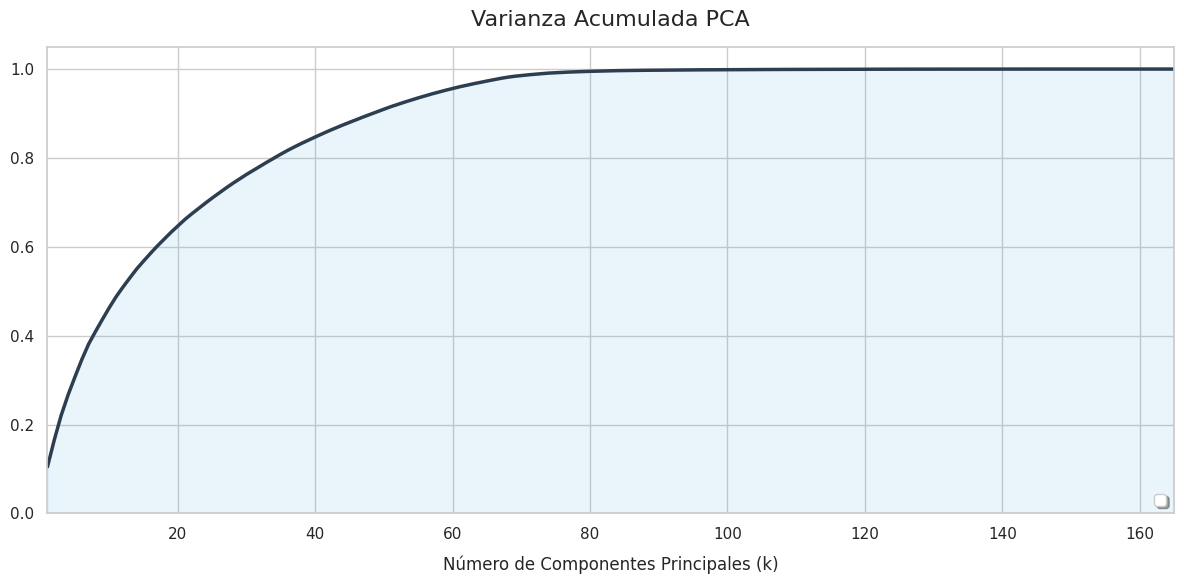

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt


k_components = range(1, len(accum_var) + 1)

sns.set_theme(style="whitegrid", context="notebook")
plt.figure(figsize=(12, 6))
sns.lineplot(
    x=k_components,
    y=accum_var,
    linewidth=2.5,
    color="#2c3e50"
)

plt.fill_between(k_components, accum_var, color="#3498db", alpha=0.1)
plt.title('Varianza Acumulada PCA', fontsize=16, pad=15)
plt.xlabel('Número de Componentes Principales (k)', fontsize=12, labelpad=10)
plt.ylim(0, 1.05)
plt.xlim(1, len(k_components))

plt.legend(loc='lower right', frameon=True, shadow=True)
plt.tight_layout()
plt.show()

Una métrica importante para explorar la topología del grafo es el grado de un nodo, que viene a ser la cantidad de aristas conectadas a un determinado vértice (en un grafo no dirigido, en uno dirigido tendremos grado de entrada y de salida). Calcularemos el grado promedio del grafo y la densidad (que es similar, ya que nos dice, a grandes rasgos, la proporción de aristas que tiene un grafo en comparación con el número máximo que podría tener).

In [20]:
n_nodes = df_features.count()
n_edges = df_edges.count()
density = n_edges / (n_nodes * (n_nodes - 1))

print(f"Nodos: {n_nodes:,}")
print(f"Aristas: {n_edges:,}")
print(f"Densidad: {density:.8f}")
print(f"Grado promedio: {n_edges / n_nodes:.2f}")

Nodos: 203,769
Aristas: 234,355
Densidad: 0.00000564
Grado promedio: 1.15


Lo que vamos a visualizar a continuación es la distribución de los nodos en escala logarítmica; es decir, cuántos nodos hay con X grado. La escala logarítmica es necesaria debido a que hay muchísimos nodos con un grado de 1 o 2 y muy pocos con grados mayores:

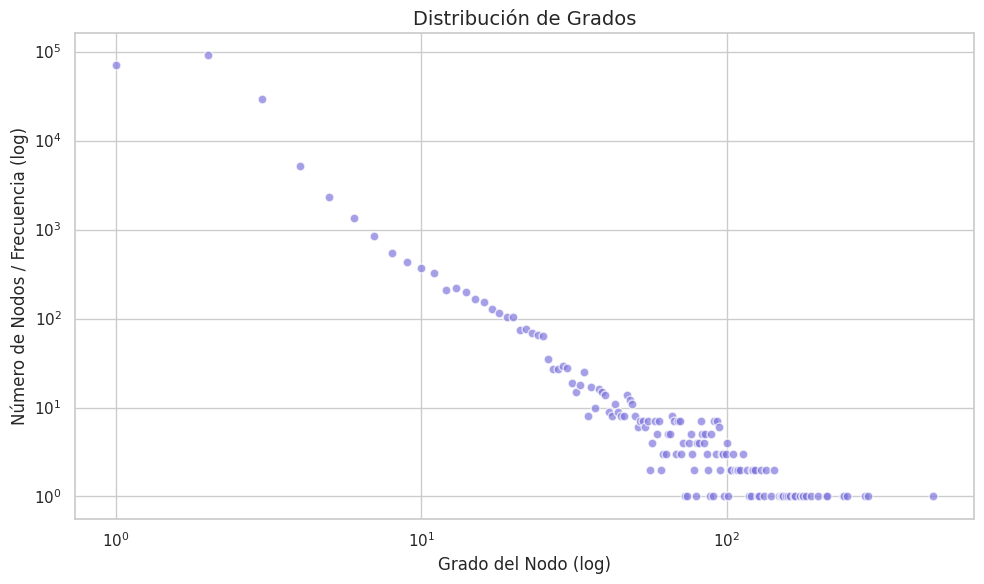

In [21]:
degree = df_edges.select(sql_f.col("src").alias("node")).union(
    df_edges.select(sql_f.col("dst").alias("node"))
).groupBy("node").agg(sql_f.count("*").alias("degree"))

degree_freq = degree.groupBy("degree").agg(
    sql_f.count("*").alias("freq")
).orderBy("degree")

degree_pd = degree_freq.toPandas()

# Graficamos usando un scatterplot
plt.figure(figsize=(10, 6))

plt.scatter(
    degree_pd["degree"],
    degree_pd["freq"],
    color="#7F77DD",
    alpha=0.7,
    edgecolors="white",
    s=40
)

# Ambos ejes en logaritmo
plt.xscale("log")
plt.yscale("log")

plt.xlabel("Grado del Nodo (log)", fontsize=12)
plt.ylabel("Número de Nodos / Frecuencia (log)", fontsize=12)
plt.title("Distribución de Grados", fontsize=14)

plt.tight_layout()
plt.show()

Como podemos ver, es un grafo muy poco denso, lo cual es algo previsible teniendo en cuenta que hay tantas componentes conexas como timesteps. Es interesante calcular el grado promedio por clase, ya que puede que nos indique alguna diferencia topológica entre transacciones lícitas e ilícitas:

In [22]:
degree_class = degree.join(
    df_classes, degree["node"] == df_classes["id"], "inner"
).drop("id").filter(sql_f.col("class") != "unknown")

degree_class.groupBy("class").agg(
    sql_f.round(sql_f.mean("degree"), 2).alias("avg_degree"),
    sql_f.round(sql_f.stddev("degree"), 2).alias("std_degree"),
    sql_f.max("degree").alias("max_degree"),
    sql_f.count("*").alias("n")
).show()

+-----+----------+----------+----------+-----+
|class|avg_degree|std_degree|max_degree|    n|
+-----+----------+----------+----------+-----+
|    1|      2.01|      7.18|       177| 4545|
|    2|       3.1|      7.78|       473|42019|
+-----+----------+----------+----------+-----+



Efectivamente, parece que hay diferencias topológicas entre clases.

## Hipótesis

Existe una estructura interesante en torno a la propiedad de la marca de tiempo (timestamp), es decir, la naturaleza de los datos consiste en componentes de grafo disjuntos. Podríamos formular aquí una hipótesis: no existe ninguna preferencia sobre en qué momento temporal pueden ocurrir las transacciones lícitas o ilícitas y, por lo tanto, podría haber cierta invarianza temporal que podríamos explotar. En cualquier caso, podemos experimentar con la partición de los datos, aplicando ya sea esta estrategia de partición u otra basada en un muestreo más clásico con reemplazo. Esto quiere decir que aplicar un enfoque local, es decir, entrenar un modelo en cada worker y después agregar, puede ser una aproximación interesante. Por otra parte, el ~90% de la varianza acumulada de los datos se explican con las primeras ~50 componentes, una reducción de la dimensionalidad podría ser razonable.

## Entrenamiento de los Modelos

No podemos entrenar basándonos únicamente en algoritmos tabulares, ya que también deseamos aprovechar la topología del grafo en sí (aunque compararemos con un baseline tabular para ver si realmente esto se mantiene). Un enfoque muy natural es utilizar GNNs (Redes Neuronales de Grafos), puesto que son capaces de agregar tanto la topología como las características de los nodos, de tal manera que un problema transductivo pueda resolverse eficazmente. Pero exploraremos también alguna combinación de algoritmo tabular junto con algún otro algoritmo de grafos para aportar, de alguna forma, información topológica a dicho algoritmo tabular.

### Resumen de las GNNs

Existen varios tipos de GNNs, pero nos centraremos en las Redes Convolucionales de Grafos (GCNs, por sus siglas en inglés). Estos modelos son convolucionales en el sentido de que actualizan cada nodo agregando información de los nodos cercanos y, como tales, inducen un sesgo inductivo relacional. Cada capa de la GCN puede describirse como una función $F[\bullet]$ con parámetros $\Phi$ que toma los embeddings de los nodos y la matriz de adyacencia y devuelve nuevos embeddings de los nodos:

$$H_1 = F[X, A, \Phi_0]$$

$$H_2 = F[H_1, A, \Phi_1]$$

$$\vdots$$

$$H_K = F[H_{K-1}, A, \Phi_{K-1}]$$
donde $X$ es la entrada, $A$ es la matriz de adyacencia, $H_k$ contiene los embeddings modificados de los nodos en la $k$-ésima capa, y $\Phi_k$ son los parámetros asociados a esa capa. A nivel de un solo nodo, tenemos:

$$h_{k+1}^{(n)} = a[\beta_k + \Omega_k \cdot h_{k}^{(n)} + \Omega_k \cdot agg[n,k]]$$
donde $a[\bullet]$ es la función de activación, $\Omega_k$ es una transformación lineal y $agg[\bullet]$ es una función de agregación sobre la vecindad del nodo, que podría ser simplemente la suma de los embeddings vecinos. A nivel de una capa completa, esto puede escribirse como:

$$H_{k+1} = a[\beta_k 1^T + \Omega_k H_{k} + \Omega_k H_k A] = a[\beta_k 1^T + \Omega_k H_{k} (A + I)]$$
De manera más informal, una GCN enriquece los embeddings de entrada de los nodos del grafo con información de su entorno, produciendo un embedding enriquecido para cada nodo. Esto hace que una GCN sea particularmente adecuada para entornos transductivos. En particular, para nuestros propósitos de clasificación binaria de nodos, la capa final debería tener la siguiente forma:

$$f[X, A, \Phi] = sig[\beta_K 1^T + w_K H_K]$$
donde $sig[\bullet]$ es una función sigmoidea que se aplica de forma independiente a cada elemento del vector fila de entrada, necesaria porque queremos establecer una distribución de probabilidad sobre las posibles etiquetas; dado que estamos en un entorno binario, no necesitamos un $softmax$. En otras palabras, al final tendremos una etiqueta predicha $y^{(n)}$ para cada nodo $n$ del grafo. La pérdida será entonces una entropía cruzada binaria habitual, pero con un par de salvedades:

- Solo se aplicará a los nodos para los que tenemos un ground truth, lo que significa que necesitaremos aplicar una máscara. Esto demuestra por qué una GNN es tan adecuada para nuestros propósitos: los nodos sin etiquetar simplemente se clasificarán como cualquier otro nodo.

- Nuestras clases están severamente desbalanceadas. Podemos aplicar aquí otras estrategias, pero la más simple es modificar la función de pérdida. Intentaremos aplicar ponderación para penalizar los errores en la clase minoritaria. La función de pérdida de entropía cruzada binaria puede escribirse como:

$$l(y, \hat{y}) = - (1 - y) \log(1 - \hat{y}) - y \log(\hat{y})$$

donde $y \in \{1, -1\}$ es el ground truth y $\hat{y} \in [0, 1]$ es la probabilidad predicha por el modelo. La entropía cruzada ponderada será simplemente:

$$l(y, \hat{y}) = - [\alpha \cdot (1 - y) \log(1 - \hat{y}) + \beta \cdot y \log(\hat{y})]$$

donde $\alpha, \beta$ son hiperparámetros, pero pueden calcularse como:

$$\alpha = \frac{N}{2 \cdot \sum_{i=1}^{N} \mathbf{1}_{A}(y_i = -1)}$$

$$\beta = \frac{N}{2 \cdot \sum_{i=1}^{N} \mathbf{1}_{A}(y_i = 1)}$$

donde $N$ es el tamaño del conjunto de datos.


### Resumen del Aprendizaje Federado

Una posible aproximación a nuestro problema de aprendizaje distribuido es usar un enfoque local para entrenar modelos en cada worker y, luego, agregar el resultado de alguna forma. Una forma natural de hacer esto es con Aprendizaje Federado. En particular, ya comentamos en el establecimiento de nuestra hipótesis que las transacciones pueden representar una distribución I.I.D. ya que no existen, a priori, dependencias temporales. El aprendizaje federado se trata de un proceso iterativo que sigue las siguientes etapas:

1. Cada cliente $i$ entrena su modelo local $LLM_i$ con sus datos locales $D_{i}^{t}$, actualizando los parámetros $\theta_{i}^{t}$ del modelo local.

2. Los clientes envían sus parámetros actualizados $\theta_{i}^{t}$ al servidor.

3. El servidor computa los parámetros globales $\theta^{t}$ agregando los parámetros locales $\{\theta_{1}^{t}, \theta_{2}^{t},... \theta_{n}^{t}\}$ con un operador de agregación $\Delta$:

$$\theta^t = \Delta(\theta_{1}^{t}, \theta_{2}^{t},... \theta_{n}^{t})$$

4. Los parámetros locales son actualizados con dicha agregación:

$$\theta_{i}^{t+1} \leftarrow \theta^{t}, \quad \forall i \in \{1, 2,... n\}$$

En particular, podemos tratar de usar un FedAvg, en donde el operador de agregación es meramente el promedio.

### Implementación

#### Pre-procesamiento

Vamos a plantear una pipeline de MLlib en donde realizaremos una estandarización y codificaremos las clases como enteros.

In [23]:
from pyspark.ml.feature import StandardScaler, StringIndexer


# Assembler
feature_cols = [f"_c{i}" for i in range(2, 167)]
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="raw_features",
    handleInvalid="skip"
)
nodes_assembled = assembler.transform(df_nodes)

# Estandarización
scaler = StandardScaler(
    inputCol="raw_features",
    outputCol="features",
    withStd=True,
    withMean=True
)
scaler_model = scaler.fit(nodes_assembled)
nodes_scaled = scaler_model.transform(nodes_assembled)

# Label encoding
labeled_vertices = nodes_scaled.filter(sql_f.col("class") != "unknown")
indexer = StringIndexer(
    inputCol="class",
    outputCol="label",
    handleInvalid="keep"
)
indexer_model = indexer.fit(labeled_vertices)
df_nodes_final = indexer_model.transform(nodes_scaled)

label_mapping = df_nodes_final.filter(sql_f.col("class") != "unknown") \
    .select("class", "label").distinct().toPandas()
print(label_mapping)

  class  label
0     1    1.0
1     2    0.0


#### Aprendizaje Federado

Empezamos con la implementación del modelo de GCN que entrenaremos en cada worker, y que, posteriormente, usaremos también de arquitectura para el modelo global que cuente con el promedio de los parámetros.

In [24]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv


class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self._conv1 = GCNConv(in_channels, hidden_channels, normalize=False)
        self._conv2 = GCNConv(hidden_channels, out_channels, normalize=False)

    def forward(self, x, edge_index, edge_weight):
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv1(x, edge_index, edge_weight).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

ModuleNotFoundError: No module named 'torch_geometric'

Como implementación distribuida, haremos uso de un UDF de Pandas para poder entrentar en cada nodo usando PyTorch Geometric.

In [ ]:
from torch_geometric.data import Data


def train(model, optimizer, data, weights):
    model.train()
    optimizer.zero_grad()

    # El forward pass se realiza sin masking.
    out = model(data.x, data.edge_index, data.edge_weight).squeeze()

    # Esta función de pérdida aplica una sigmoide y una entropía cruzada
    # binaria ponderada.
    loss = torch.nn.BCEWithLogitsLoss(weight=weights)

    # El backward pass sí que necesita masking.
    output = loss(out[data.train_mask], data.y[data.train_mask].float())
    output.backward()
    optimizer.step()

    return float(output.detach())

def local_gcn(bc_global_weights, local_epochs=3):
    def train_local_gcn(pdf_iterator):
        # Spark devuelve la partición como un iterator con apache arrow.
        pdf = pd.concat(list(pdf_iterator))
        row = pdf.iloc[0]

        # Tensores con los datos.
        x = torch.tensor(row['features'], dtype=torch.float)
        edge_index = torch.tensor(row['edge_index'], dtype=torch.long).t().contiguous()
        y = torch.tensor(row['label'], dtype=torch.long)
        num_nodes = x.size(0)

        # Los índices de los nodos deben de estar en el intervalo [0, N-1]
        # para que PyTorch Geometric los consuma correctamente. Realizamos
        # la traducción.
        id_map = {
            global_id: local_id
            for local_id, global_id in enumerate(row['node_ids'])
        }

        local_edges = []
        if row['edge_pair'] is not None:
            for src_global, dst_global in row['edge_pair']:
                if src_global in id_map and dst_global in id_map:
                    src_local = id_map[src_global]
                    dst_local = id_map[dst_global]
                    local_edges.append([src_local, dst_local])

        # Convertimos a tensor. Si no hay aristas, creamos un tensor vacío con la forma correcta [2, 0]
        if len(local_edges) > 0:
            edge_index = torch.tensor(local_edges, dtype=torch.long).t().contiguous()
        else:
            edge_index = torch.empty((2, 0), dtype=torch.long)

        # Calcula los pesos para la función de pérdida ponderada.
        w_0 = num_nodes / (2 * pdf.where(pdf["label"] == 1.0).values.sum())
        w_1 = num_nodes / (2 * pdf.where(pdf["label"] == 0.0).values.sum())
        weights = torch.tensor([w_0, w_1])

        # Masking.
        mask = ((y == 0.0) | (y == 1.0))

        # PyG Data object que representa el grafo.
        data = Data(
            x=x, edge_index=edge_index,
            y=y, train_mask=mask, val_mask=mask,
            test_mask=mask
        )

        model = GCN(
            in_channels=x.shape[1], hidden_channels=16,
            out_channels=2,
        ).to('cpu')

        # Carga de los pesos globales
        model.load_state_dict(bc_global_weights.value)

        optimizer = torch.optim.Adam([
            dict(params=model.conv1.parameters(), weight_decay=5e-4),
            dict(params=model.conv2.parameters(), weight_decay=0)
        ], lr=0.01)

        # Entrena en full batch.
        for _ in range(local_epochs):
            loss = train(model, optimizer, data, weights)

        state_dict = model.state_dict()
        dfs = []
        for layer_name, tensor in state_dict.items():
            # Aplana el tensor a un vector 1D.
            flat_array = tensor.cpu().detach().numpy().flatten()

            # Dataframe temporal para esta capa con los índices.
            layer_df = pd.DataFrame({
                'layer_name': layer_name,
                'param_index': np.arange(len(flat_array)),
                'param_value': flat_array
            })
            dfs.append(layer_df)

        exploded_weights = pd.concat(dfs, ignore_index=True)
        exploded_weights['partition_id'] = row['partition_id']
        exploded_weights['n_samples'] = num_nodes

        yield exploded_weights

    return train_local_gcn

Necesitamos implementar la partición del grafo por timestep para el entrenamiento de cada uno de los workers.

In [ ]:
def timestep_partition(df_nodes, df_edges):
    # Particionamos los nodos por timestep, según los hilos
    # de cpu disponibles.
    cpu_threads = sc.defaultParallelism
    df_nodes = df_nodes.repartition(cpu_threads, "timestep")
    df_nodes = df_nodes.withColumn("partition_id", sql_f.spark_partition_id())

    # Asignamos partition_id_src a las aristas
    df_edges = df_edges.join(
        df_nodes.select(
            sql_f.col("id").alias("src"),
            sql_f.col("partition_id").alias("partition_id_src")
        ),
        on="src", how="inner"
    )

    # Asignamos partition_id_dst y filtramos aristas inter-partición.
    # Este filtro es necesario, debido a que, si no filtramos las aristas
    # entre partición (aunque sepamos que no las haya, por el EDA) la
    # convolución buscará el nodo que se encuentre fuera de la partición
    # y fallará.
    df_edges = df_edges.join(
        df_nodes.select(
            sql_f.col("id").alias("dst"),
            sql_f.col("partition_id").alias("partition_id_dst")
        ),
        on="dst", how="inner"
    ).filter(sql_f.col("partition_id_src") == sql_f.col("partition_id_dst")) \
        .drop("partition_id_dst").withColumnRenamed("partition_id_src", "partition_id")

    # Colapsamos las columnas en listas agrupadas por el partition_id.
    # Esto es necesario para alimentar correctamente a la UDF, ya que esta
    # espera un iterador de pandas en donde el grafo entero sea una lista.
    df_nodes_agg = df_nodes.groupBy("partition_id").agg(
        sql_f.collect_list("id").alias("node_id"),
        sql_f.collect_list("timestep").alias("timestep"),
        sql_f.collect_list("features").alias("features"),
        sql_f.collect_list("label").alias("label")
    )

    # Colapsamos las aristas de una forma similar para poder hacer el join
    # con el dataframe anterior.
    df_edges_agg = df_edges.withColumn("edge_pair", sql_f.array("src", "dst")) \
        .groupBy("partition_id").agg(
            sql_f.collect_list("edge_pair").alias("edge_pair")
        )

    # Unir ambos dataframes colapsados por partición.
    df_data = df_nodes_agg.join(df_edges_agg, on="partition_id", how="left")
    return df_data

Implementaremos ahora el proceso principal de Spark y el propio aprendizaje federado.

In [ ]:
@torch.no_grad
def test(model, data):
    model.eval()
    pred = model(data.x, data.edge_index, data.edge_weight).squeeze().argmax(dim=-1)

    accs = []
    for mask in [data.train_mask, data.val_mask, data.test_mask]:
        accs.append(int((pred[mask] == data.y[mask]).sum()) / int(mask.sum()))
    return accs

In [ ]:
import random
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, FloatType


ROUNDS = 50
LOCAL_EPOCHS = 3

# Esquema de salida de la UDF.
schema_output = StructType([
    StructField("layer_name", StringType(), True),
    StructField("param_index", IntegerType(), True),
    StructField("param_value", FloatType(), True),
    StructField("partition_id", StringType(), True),
    StructField("n_samples", IntegerType(), True)
])

# Realizamos la partición por timestep.
df_data = timestep_partition(df_nodes, df_edges)

# Hold-out para evaluación. Buscamos un conjunto de test
# que pueda caber en memoria del driver.
df_train, df_val, df_test = df_data.randomSplit([0.8, 0.1, 0.1], seed=42)

def pdf_to_pyg(pdf):
    row = pdf.iloc[0]
    y = torch.tensor(row['class'], dtype=torch.long)
    mask = ((y == 0.0) | (y == 1.0))

    return Data(
        x=torch.tensor(row['features'], dtype=torch.float),
        edge_index=torch.tensor(row['edge_index'], dtype=torch.long).t().contiguous(),
        y=y, train_mask=mask, val_mask=mask, test_mask=mask
    )

# Recolectamos los grafos de validación para evaluarlos en el driver
val_graphs = [pdf_to_pyg(p) for p in df_val.toPandas().groupby('partition_id').apply(lambda x: x)]

# Inicializa el modelo global en el driver.
num_features = len(feature_cols) - 1
global_model = GCN(in_channels=num_features, hidden_channels=16, out_channels=2)
global_weights = global_model.state_dict()

# Bucle global de FedAvg.
history = {"round": [], "val_acc": [], "train_loss_approx": []}
for round_num in range(ROUNDS):
    print(f"--- Global Round {round_num + 1}/{ROUNDS} ---")

    # Broadcast de los pesos actuales.
    bc_weights = sc.broadcast(global_weights)

    # Se lanza la UDF para cada partición.
    udf = local_gcn(bc_weights, local_epochs=LOCAL_EPOCHS)
    df_updates = df_train.mapInPandas(udf, schema=schema_output)

    # Obtener la suma total de nodos de las particiones que han participado.
    # Cacheamos df_updates para no recalcular el entrenamiento al hacer la agregación.
    df_updates.cache()
    total_samples_row = df_updates.select("partition_id", "n_samples")\
                                  .distinct()\
                                  .agg(sql_f.sum("n_samples").alias("total"))\
                                  .collect()[0]
    total_samples = total_samples_row['total']

    # Calculamos los promedios de los parámetros.
    aggregated_df = df_updates.withColumn(
        "weighted_val",
        sql_f.col("param_value") * (sql_f.col("n_samples") / total_samples)
    ).groupBy("layer_name", "param_index")\
        .agg(sql_f.sum("weighted_val").alias("new_param_value"))\
        .orderBy("layer_name", "param_index")

    # Recolecta al driver y reconstruye el state_dict.
    new_weights = aggregated_df.toPandas()
    df_updates.unpersist() # Liberar memoria

    for layer_name in global_weights.keys():
        layer_data = new_weights[new_weights['layer_name'] == layer_name]

        # Recuperamos la forma original del tensor en la capa global.
        original_shape = global_weights[layer_name].shape

        # Convertimos la columna a un array numpy y la redimensionamos.
        new_layer_array = layer_data['new_param_value'].values.reshape(original_shape)

        # Actualizamos el diccionario global.
        global_weights[layer_name] = torch.tensor(new_layer_array, dtype=torch.float32)

    # Evaluación del modelo global.
    global_model.load_state_dict(global_weights)
    val_acc = test(global_model, val_graphs)

    # Guardar métricas.
    history["round"].append(round_num)
    history["val_acc"].append(val_acc)
    print(f"Round {round_num}: Global Validation Accuracy = {val_acc:.4f}")

    df_updates.unpersist()

# Evaluación del conjunto de test.
test_graphs = [pdf_to_pyg(p) for p in df_test.toPandas().groupby('partition_id').apply(lambda x: x)]
final_test_acc = test(global_model, test_graphs)
print(f"\nGlobal Test Accuracy: {final_test_acc:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(history["round"], history["val_acc"], label="Global Validation Accuracy", marker='o')
plt.title("Convergencia del Aprendizaje Federado (FedAvg)")
plt.xlabel("Rondas de Comunicación")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()